In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
precipitation = pd.Series([45, 42, 45, 60, 90, 105, 110, 95, 60, 50, 52, 48])
city = "Івано-Франківськ"

print(f"Дані для міста {city} завантажено успішно.")

Дані для міста Івано-Франківськ завантажено успішно.


In [2]:
var_series = np.sort(precipitation.values)
print(" Варіаційний ряд (опади за зростанням, мм) ")
print(var_series)

bins = [40, 60, 80, 100, 120]
labels = ["40–60", "60–80", "80–100", "100–120"]

categories = pd.cut(precipitation, bins=bins, labels=labels, right=True)

freq = categories.value_counts().sort_index()
rel_freq = categories.value_counts(normalize=True).sort_index() * 100
cum_freq = freq.cumsum()
cum_rel_freq = rel_freq.cumsum()

freq_table = pd.DataFrame(
    {
        "Абсолютна частота": freq,
        "Відносна частота (%)": rel_freq.round(1),
        "Накопичена частота (абс)": cum_freq,
        "Накопичена відносна (%)": cum_rel_freq.round(1),
    }
)

print("\n Частотна таблиця за інтервалами ")
print(freq_table)

 Варіаційний ряд (опади за зростанням, мм) 
[ 42  45  45  48  50  52  60  60  90  95 105 110]

 Частотна таблиця за інтервалами 
         Абсолютна частота  Відносна частота (%)  Накопичена частота (абс)  \
40–60                    8                  66.7                         8   
60–80                    0                   0.0                         8   
80–100                   2                  16.7                        10   
100–120                  2                  16.7                        12   

         Накопичена відносна (%)  
40–60                       66.7  
60–80                       66.7  
80–100                      83.3  
100–120                    100.0  


Кількість спостережень (n): 12
Кількість інтервалів за правилом √n: 4
Кількість інтервалів за правилом Стерджеса: 5


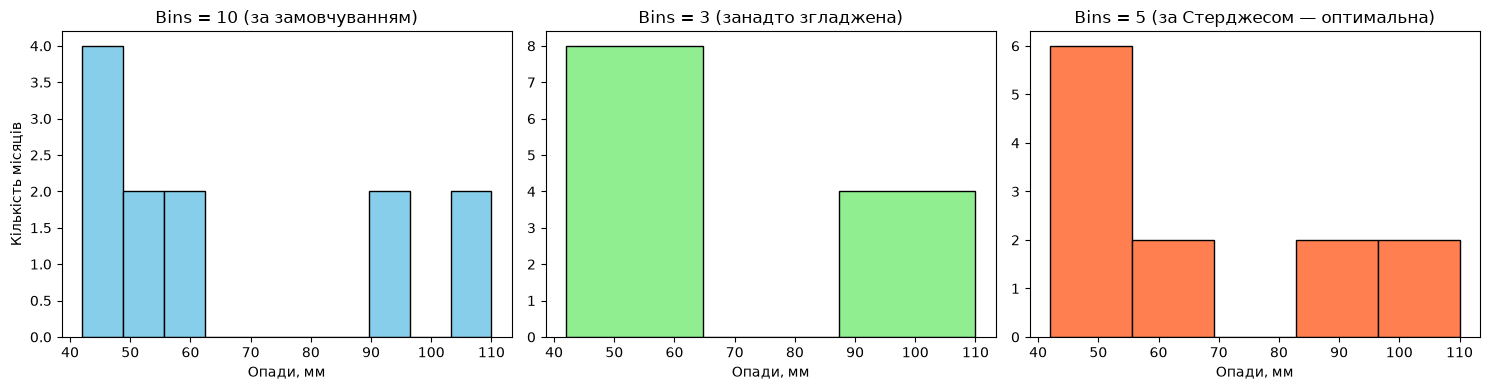

In [3]:
n = len(precipitation)
sturges_bins = int(np.ceil(1 + math.log2(n)))  # 1 + log2(12) ≈ 4.58 -> 5
sqrt_bins = int(np.ceil(np.sqrt(n)))  # sqrt(12) ≈ 3.46 -> 4

print(f"Кількість спостережень (n): {n}")
print(f"Кількість інтервалів за правилом √n: {sqrt_bins}")
print(f"Кількість інтервалів за правилом Стерджеса: {sturges_bins}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(precipitation, bins=10, color="skyblue", edgecolor="black")
axes[0].set_title("Bins = 10 (за замовчуванням)")
axes[0].set_xlabel("Опади, мм")
axes[0].set_ylabel("Кількість місяців")

axes[1].hist(precipitation, bins=3, color="lightgreen", edgecolor="black")
axes[1].set_title("Bins = 3 (занадто згладжена)")
axes[1].set_xlabel("Опади, мм")

axes[2].hist(precipitation, bins=5, color="coral", edgecolor="black")
axes[2].set_title("Bins = 5 (за Стерджесом — оптимальна)")
axes[2].set_xlabel("Опади, мм")

plt.tight_layout()
plt.show()

In [4]:
mean_val = precipitation.mean()
median_val = precipitation.median()
mode_val = precipitation.mode().tolist()  # Може бути кілька мод

q1 = precipitation.quantile(0.25)
q3 = precipitation.quantile(0.75)

print(" Завдання 4: Основні статистики ")
print(f"Середнє значення (Mean): {mean_val:.2f} мм")
print(f"Медіана (Median): {median_val:.2f} мм")
print(f"Мода (Mode): {mode_val} мм")
print(f"Q1 (25-й процентиль): {q1:.2f} мм")
print(f"Q3 (75-й процентиль): {q3:.2f} мм")

 Завдання 4: Основні статистики 
Середнє значення (Mean): 66.83 мм
Медіана (Median): 56.00 мм
Мода (Mode): [45, 60] мм
Q1 (25-й процентиль): 47.25 мм
Q3 (75-й процентиль): 91.25 мм
